# Day 11: Naive Bayes, SVM, K-Means, and PCA

## Text Classification, Nonlinear Boundaries, Unsupervised Learning, and Dimensionality Reduction

This notebook transitions from supervised classification into unsupervised learning.

We will cover:

- Naive Bayes for NLP text classification
- CountVectorizer and Bag-of-Words
- Support Vector Machines
- RBF kernel and nonlinear decision boundaries
- K-Means clustering
- Elbow Method
- Principal Component Analysis
- Silhouette Score

---

# Setup

In Google Colab, these libraries are usually already installed.

If students get an import error, run:

```python
!pip install scikit-learn matplotlib seaborn pandas numpy
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

print("Day 11 Advanced ML Models Environment Initialized.")
np.random.seed(42)

Day 11 Advanced ML Models Environment Initialized.


---

# 1. Naive Bayes for NLP Text Classification

Naive Bayes is a fast and effective algorithm for text classification.

It is commonly used for spam detection, sentiment analysis, news classification, language identification, and topic classification.

Text cannot be given directly to most machine learning models. First, we convert text into numbers using `CountVectorizer`.

`CountVectorizer` creates a Bag-of-Words frequency matrix where each row is a sentence and each column is a word.

In [2]:
texts = [
    "This is a Tamil morphological parser",
    "Analyzing Kannada syntax structures",
    "Telugu natural language processing",
    "Hindi grammar analysis model",
    "Marathi sentence translation",
    "Gujarati text vectorization"
]

labels = [0, 0, 0, 1, 1, 1]

model_nb = make_pipeline(CountVectorizer(), MultinomialNB())
model_nb.fit(texts, labels)

test_texts = ["Building a parser for Tamil text", "Hindi language processing"]
predictions = model_nb.predict(test_texts)

print("Naive Bayes Predictions:")
for text, pred in zip(test_texts, predictions):
    class_name = "Dravidian" if pred == 0 else "Indo-Aryan"
    print(f"'{text}' -> {class_name}")

Naive Bayes Predictions:
'Building a parser for Tamil text' -> Dravidian
'Hindi language processing' -> Dravidian


## Extra: See the Bag-of-Words Matrix

This lets students see how text is converted into a numerical table.

In [3]:
vectorizer = CountVectorizer()
X_text_counts = vectorizer.fit_transform(texts)

bow_df = pd.DataFrame(
    X_text_counts.toarray(),
    columns=vectorizer.get_feature_names_out()
)

display(bow_df)

,analysis,analyzing,grammar,gujarati,hindi,is,kannada,language,marathi,model,...,processing,sentence,structures,syntax,tamil,telugu,text,this,translation,vectorization
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
1,0,1,0,0,0,0,1,0,0,0,...,0,0,1,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,1,0,0,0,0
3,1,0,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
5,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1


## Extra: Predict Class Probabilities

Naive Bayes can estimate probabilities for each class.

In [4]:
class_probabilities = model_nb.predict_proba(test_texts)

for text, probs in zip(test_texts, class_probabilities):
    print(f"Text: {text}")
    print(f"Probability Dravidian: {probs[0]:.4f}")
    print(f"Probability Indo-Aryan: {probs[1]:.4f}")
    print("-" * 50)

Text: Building a parser for Tamil text
Probability Dravidian: 0.6064
Probability Indo-Aryan: 0.3936
--------------------------------------------------
Text: Hindi language processing
Probability Dravidian: 0.6064
Probability Indo-Aryan: 0.3936
--------------------------------------------------


---

# 2. Support Vector Machines and the Kernel Trick

A Support Vector Machine tries to find a boundary that separates classes.

For simple data, a straight line may separate the classes. But real-world data is often nonlinear.

The RBF kernel helps SVM create curved decision boundaries.

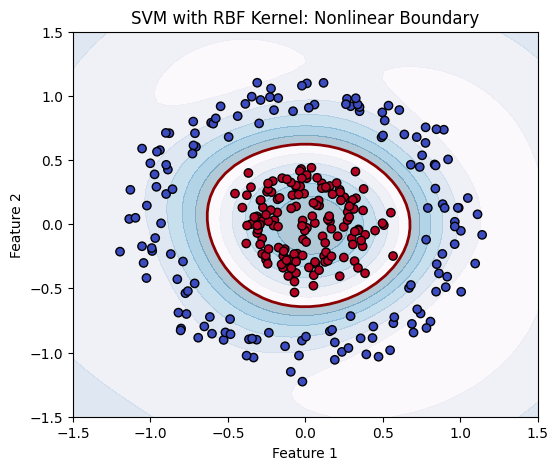

In [5]:
X_circle, y_circle = make_circles(
    n_samples=300,
    noise=0.1,
    factor=0.3,
    random_state=42
)

svm_model = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_model.fit(X_circle, y_circle)

xx, yy = np.meshgrid(
    np.linspace(-1.5, 1.5, 50),
    np.linspace(-1.5, 1.5, 50)
)

Z = svm_model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap=plt.cm.PuBu, alpha=0.3)
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors="darkred")
plt.contourf(xx, yy, Z, levels=np.linspace(0, Z.max(), 7), cmap=plt.cm.PuBu, alpha=0.3)
plt.scatter(X_circle[:, 0], X_circle[:, 1], c=y_circle, cmap=plt.cm.coolwarm, edgecolors="k")
plt.title("SVM with RBF Kernel: Nonlinear Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Extra: Linear SVM vs RBF SVM

This comparison shows why the kernel trick matters.

In [6]:
linear_svm = SVC(kernel="linear")
rbf_svm = SVC(kernel="rbf", gamma="scale")

linear_svm.fit(X_circle, y_circle)
rbf_svm.fit(X_circle, y_circle)

print(f"Linear SVM Accuracy: {linear_svm.score(X_circle, y_circle) * 100:.2f}%")
print(f"RBF SVM Accuracy: {rbf_svm.score(X_circle, y_circle) * 100:.2f}%")

Linear SVM Accuracy: 66.67%
RBF SVM Accuracy: 100.00%


---

# 3. K-Means Clustering: Operating Without Labels

We are now entering unsupervised learning.

In supervised learning, we have labels. In unsupervised learning, the model must discover structure by itself.

K-Means groups similar points together.

Here we create student behavior data using platform logins and assignment completion time.

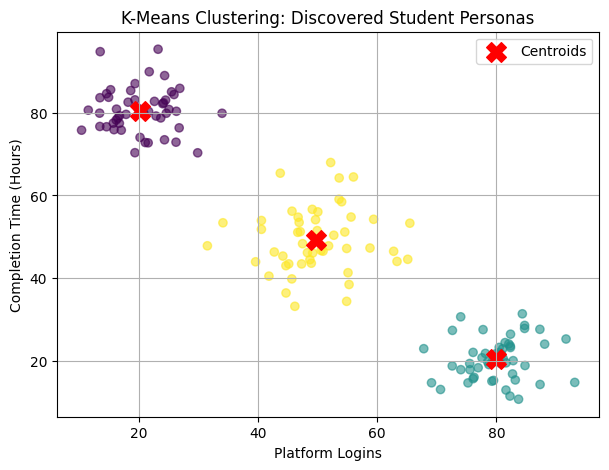

In [7]:
g1 = np.random.normal(loc=[80, 20], scale=[5, 5], size=(50, 2))
g2 = np.random.normal(loc=[20, 80], scale=[5, 5], size=(50, 2))
g3 = np.random.normal(loc=[50, 50], scale=[8, 8], size=(50, 2))

X_behavior = np.vstack((g1, g2, g3))

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_behavior)
centroids = kmeans.cluster_centers_

plt.figure(figsize=(7, 5))
plt.scatter(X_behavior[:, 0], X_behavior[:, 1], c=cluster_labels, cmap="viridis", alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], c="red", marker="X", s=200, label="Centroids")
plt.title("K-Means Clustering: Discovered Student Personas")
plt.xlabel("Platform Logins")
plt.ylabel("Completion Time (Hours)")
plt.legend()
plt.grid(True)
plt.show()

## Extra: Cluster Centers as a Table

The centroid gives the average profile of each discovered group.

In [8]:
centroid_df = pd.DataFrame(
    centroids,
    columns=["Platform_Logins", "Completion_Time_Hours"]
)

centroid_df["Cluster"] = range(len(centroid_df))
display(centroid_df)

,Platform_Logins,Completion_Time_Hours,Cluster
0,20.150300,80.500512,0
1,80.019694,20.501012,1
2,49.724159,49.314433,2


---

# 4. The Elbow Method

In the previous cell, we guessed `K = 3`.

The Elbow Method helps us choose K.

K-Means calculates WCSS, called `inertia_` in scikit-learn. As K increases, WCSS decreases.

The elbow point is a good choice for K.

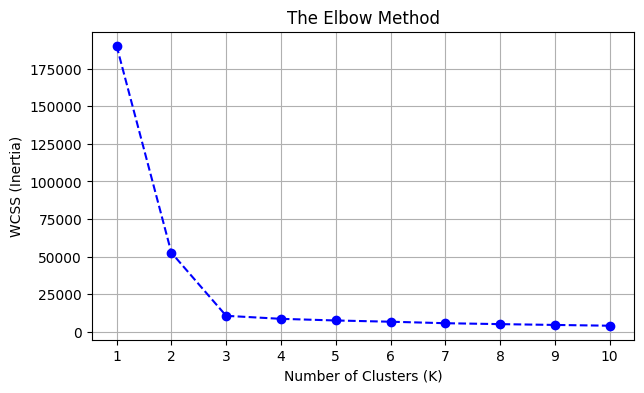

The sharp bend, or elbow, appears around K=3.


In [9]:
wcss = []
k_range = range(1, 11)

for i in k_range:
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_behavior)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, wcss, marker="o", linestyle="--", color="b")
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

print("The sharp bend, or elbow, appears around K=3.")

## Extra: Silhouette Scores for Different K Values

Silhouette Score measures how well-separated clusters are.

It ranges from -1 to +1. Higher is better.

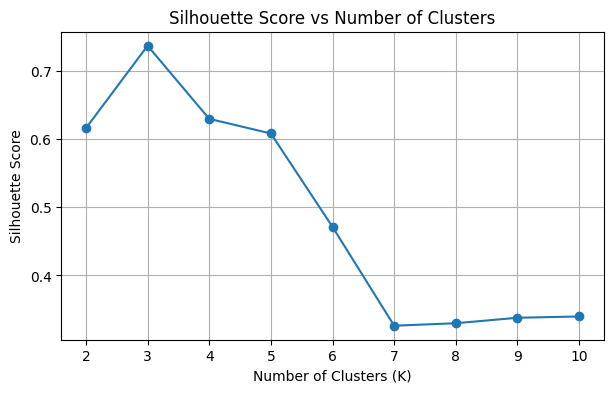

Best K by silhouette score: 3


In [10]:
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_behavior)
    score = silhouette_score(X_behavior, labels_k)
    silhouette_scores.append(score)

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), silhouette_scores, marker="o")
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

best_k_silhouette = list(k_values)[np.argmax(silhouette_scores)]
print(f"Best K by silhouette score: {best_k_silhouette}")

---

# 5. Principal Component Analysis and Silhouette Score

High-dimensional data cannot be easily plotted.

PCA compresses high-dimensional data into fewer dimensions.

Here we compress 5D data into 2D.

Always scale data before PCA because PCA is affected by feature scale.

Original shape: (150, 5)
Compressed shape: (150, 2)
Variance Retained: 49.70%

Silhouette Score: 0.3427


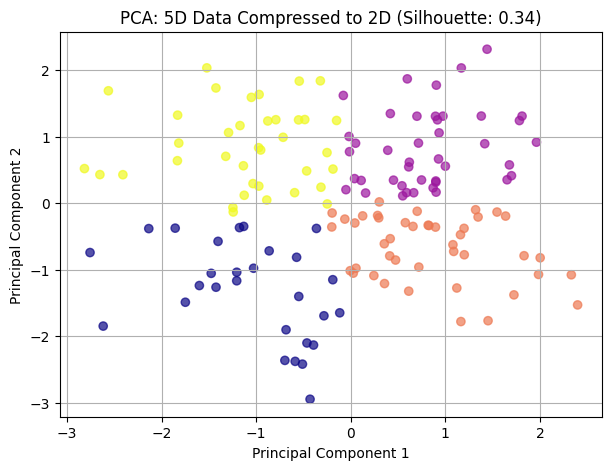

In [11]:
X_high_dim = np.random.rand(150, 5) * 100

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_high_dim)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Original shape: {X_scaled.shape}")
print(f"Compressed shape: {X_pca.shape}")
print(f"Variance Retained: {np.sum(pca.explained_variance_ratio_) * 100:.2f}%\n")

km_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
pca_labels = km_pca.fit_predict(X_pca)

sil_score = silhouette_score(X_pca, pca_labels)
print(f"Silhouette Score: {sil_score:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pca_labels, cmap="plasma", alpha=0.7)
plt.title(f"PCA: 5D Data Compressed to 2D (Silhouette: {sil_score:.2f})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

## Extra: PCA Explained Variance Plot

Explained variance tells us how much information each principal component captures.

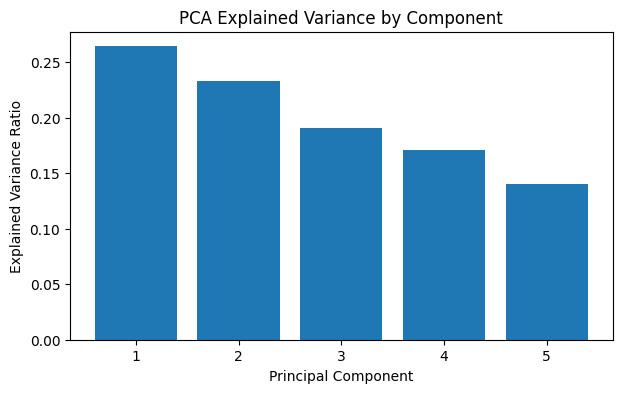

Explained variance ratio:
PC1: 0.2643
PC2: 0.2327
PC3: 0.1910
PC4: 0.1712
PC5: 0.1407


In [12]:
pca_full = PCA(n_components=5)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), explained)
plt.title("PCA Explained Variance by Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1, 6))
plt.show()

print("Explained variance ratio:")
for i, ratio in enumerate(explained, start=1):
    print(f"PC{i}: {ratio:.4f}")

---

# Supervised vs Unsupervised Summary

| Learning Type | Has Labels? | Example Model | Example Task |
|---|---|---|---|
| Supervised | Yes | Naive Bayes, SVM | Predict language class |
| Unsupervised | No | K-Means, PCA | Discover student groups |

In [13]:
summary_df = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM", "K-Means", "PCA"],
    "Learning Type": ["Supervised", "Supervised", "Unsupervised", "Unsupervised"],
    "Main Use": [
        "Text classification",
        "Complex decision boundaries",
        "Clustering similar points",
        "Dimensionality reduction"
    ]
})

display(summary_df)

,Model,Learning Type,Main Use
0,Naive Bayes,Supervised,Text classification
1,SVM,Supervised,Complex decision boundaries
2,K-Means,Unsupervised,Clustering similar points
3,PCA,Unsupervised,Dimensionality reduction


---

# Day 11 Hands-On Coding Test

The following problems are for students to solve independently.

No solutions are provided in this test section.

# Test 1: Easy  
## Naive Bayes Text Classification

Create the following text dataset:

```python
texts = [
    "good excellent amazing",
    "happy good nice",
    "bad terrible poor",
    "awful bad worst"
]

labels = [1, 1, 0, 0]
```

Here:

```text
1 = Positive
0 = Negative
```

Write Python code to:

1. Create a pipeline using `CountVectorizer()` and `MultinomialNB()`
2. Train the model
3. Predict the sentiment of `["good amazing", "bad awful"]`
4. Print each test sentence and its predicted class name

In [ ]:
# Test 1 Student Code

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

texts = [
    "good excellent amazing",
    "happy good nice",
    "bad terrible poor",
    "awful bad worst"
]

labels = [1, 1, 0, 0]

test_texts = ["good amazing", "bad awful"]

# Write your solution here

---

# Test 2: Medium  
## SVM on Nonlinear Data

Write Python code to:

1. Generate a circles dataset using:

```python
make_circles(n_samples=200, noise=0.08, factor=0.4, random_state=10)
```

2. Train an SVM using `kernel="rbf"`
3. Print the training accuracy
4. Create a scatter plot of the data colored by class label

In [ ]:
# Test 2 Student Code

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC

# Write your solution here

---

# Test 3: Hard  
## K-Means, Elbow Method, and Silhouette Score

Create three synthetic clusters:

```python
np.random.seed(5)
c1 = np.random.normal(loc=[20, 20], scale=[4, 4], size=(40, 2))
c2 = np.random.normal(loc=[70, 20], scale=[4, 4], size=(40, 2))
c3 = np.random.normal(loc=[45, 70], scale=[4, 4], size=(40, 2))
X_cluster = np.vstack((c1, c2, c3))
```

Write Python code to:

1. Run K-Means for K values from 1 to 8
2. Store WCSS values
3. Plot the Elbow Method graph
4. Train a final K-Means model with `n_clusters=3`
5. Calculate the Silhouette Score
6. Plot the final clusters with centroids
7. Print the Silhouette Score

In [ ]:
# Test 3 Student Code

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(5)
c1 = np.random.normal(loc=[20, 20], scale=[4, 4], size=(40, 2))
c2 = np.random.normal(loc=[70, 20], scale=[4, 4], size=(40, 2))
c3 = np.random.normal(loc=[45, 70], scale=[4, 4], size=(40, 2))
X_cluster = np.vstack((c1, c2, c3))

# Write your solution here

---

# End of Day 11 Notebook

By the end of this notebook, students should understand:

- How text becomes a numerical matrix using CountVectorizer
- Why Naive Bayes works well for text classification
- How SVM handles nonlinear boundaries using RBF kernels
- The difference between supervised and unsupervised learning
- How K-Means discovers clusters without labels
- How the Elbow Method helps choose K
- How Silhouette Score evaluates cluster quality
- Why PCA is used for dimensionality reduction
- Why scaling is important before PCA